In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

def mse_loss(predicted, actual):
    return np.mean((predicted - actual)**2)

actual = np.array([300, 250, 400, 150])
predicted = np.array([290, 240, 390, 160])

loss = mse_loss(predicted, actual)
print("Loss" , loss)

perfect_pred = np.array([300, 250, 400, 150])
print(f"Perfect prediction loss: {mse_loss(perfect_pred, actual):.2f}")

Loss 100.0
Perfect prediction loss: 0.00


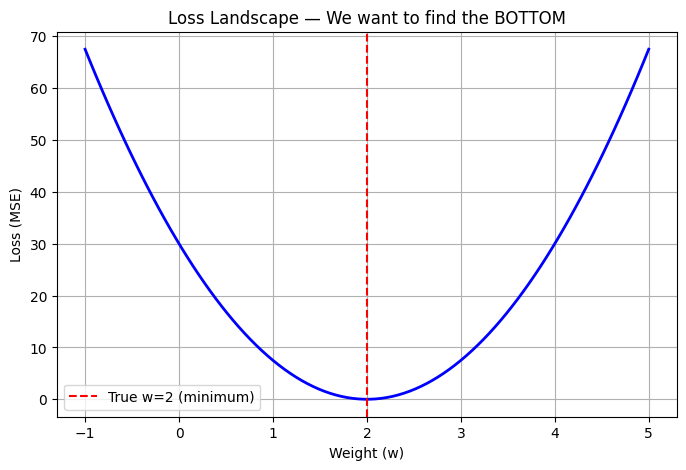

Minimum loss is at w ≈ 1.97


In [4]:
# y = wx (one weight, no bias)
# True relationship: y = 2x

X = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.0, 4.0, 6.0, 8.0])   # true: w=2

w_values = np.linspace(-1, 5, 100)
losses = []

for w in w_values:
    predictions = w * X
    loss = np.mean((predictions - y) ** 2)
    losses.append(loss)

plt.figure(figsize=(8, 5))
plt.plot(w_values, losses, 'b-', linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', label='True w=2 (minimum)')
plt.xlabel("Weight (w)")
plt.ylabel("Loss (MSE)")
plt.title("Loss Landscape — We want to find the BOTTOM")
plt.legend()
plt.grid(True)
plt.show()

print(f"Minimum loss is at w ≈ {w_values[np.argmin(losses)]:.2f}")

In [8]:
# Data: y = 2x (we want the network to learn w=2)
X = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([2.0, 4.0, 6.0, 8.0])

w = 0.0 
lr = 0.01     # learning rate as to how big each step is 
epochs = 100  # The number of times we update 

loss_history = []
w_history = []

for epoch in range(epochs):
    predictions  = w * X  
    loss = np.mean((predictions - y) ** 2 )
    gradient = np.mean(2 * (predictions - y) * X)
    w = w - lr * gradient 

    loss_history.append(loss)
    w_history.append(w)

    if epoch % 10 == 0 :
         print(f"Epoch {epoch:3d} | w: {w:.4f} | Loss: {loss:.4f}")

print(f"\nFinal learned weight: {w:.4f} (should be close to 2.0)")

Epoch   0 | w: 0.3000 | Loss: 30.0000
Epoch  10 | w: 1.6653 | Loss: 1.1628
Epoch  20 | w: 1.9341 | Loss: 0.0451
Epoch  30 | w: 1.9870 | Loss: 0.0017
Epoch  40 | w: 1.9974 | Loss: 0.0001
Epoch  50 | w: 1.9995 | Loss: 0.0000
Epoch  60 | w: 1.9999 | Loss: 0.0000
Epoch  70 | w: 2.0000 | Loss: 0.0000
Epoch  80 | w: 2.0000 | Loss: 0.0000
Epoch  90 | w: 2.0000 | Loss: 0.0000

Final learned weight: 2.0000 (should be close to 2.0)


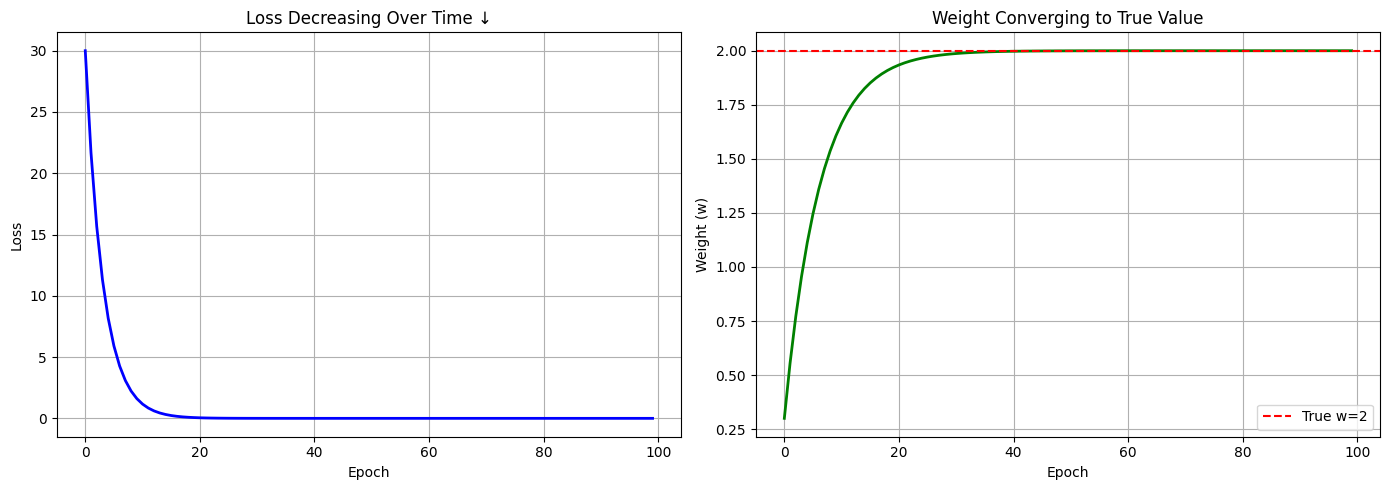

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss going down over time
ax1.plot(loss_history, 'b-', linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Decreasing Over Time ↓")
ax1.grid(True)

# Plot 2: Weight converging to true value
ax2.plot(w_history, 'g-', linewidth=2)
ax2.axhline(y=2.0, color='red', linestyle='--', label='True w=2')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Weight (w)")
ax2.set_title("Weight Converging to True Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


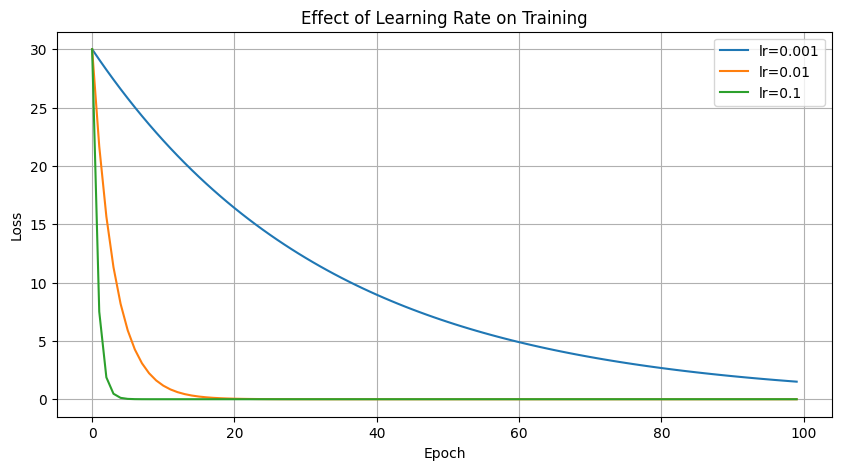

In [ ]:
# For different learning rates

learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    w = 0.0
    losses = []
    for _ in range(100):
        pred     = w * X
        loss     = np.mean((pred - y) ** 2)
        gradient = np.mean(2 * (pred - y) * X)
        w        = w - lr * gradient
        losses.append(loss)
    plt.plot(losses, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Training")
plt.legend()
plt.grid(True)
plt.show()

# Trying at 1 as learning rate the graph overshoots replace value and see plot